# **Introduction**

Online shopping has become an essential part of the global economy, and understanding customer behavior is key to increasing sales and improving user experience. Every visit to an online store generates valuable data about how shoppers browse, how long they stay on certain pages, and what actions they take before deciding to buy or leave. By studying these behaviors, businesses can predict which visitors are most likely to make a purchase and use that knowledge to create better marketing strategies. The purpose of this project is to use machine learning to predict the purchasing intentions of online shoppers, helping e-commerce companies make informed decisions that can improve customer engagement and increase revenue.

This project uses the Online Shoppers Purchasing Intention Dataset from the UCI Machine Learning Repository, which includes more than twelve thousand user sessions and eighteen behavioral and contextual features. We will use clustering, classification, and deep learning methods to predict whether a shopper will complete a purchase. The process involves cleaning and preparing the data, identifying behavioral patterns through K-Means clustering, and building predictive models such as Logistic Regression, Support Vector Machine, XGBoost, and Multilayer Perceptron. The models will then be compared and combined using a Voting Classifier to achieve the most accurate results. Evaluation will focus on recall and F1-score since these measures are best for understanding model performance on imbalanced data. Overall, this project aims to build a reliable system that can help online retailers better understand their customers and improve conversion rates.

# **Data Loading**

In [88]:
!pip install ucimlrepo
!pip install imblearn
!pip install xgboost

In [89]:
# Referred Gemini LLM for options on python libraries for various tasks like mutual info, binomial regression,SMOTE,Model Training and Validation etc.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [90]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468)

# load data
X = online_shoppers_purchasing_intention_dataset.data.features
y = online_shoppers_purchasing_intention_dataset.data.targets

# metadata
print(online_shoppers_purchasing_intention_dataset.metadata)

# variable information
print(online_shoppers_purchasing_intention_dataset.variables)

df= pd.concat([X, y], axis=1)

#print features
display(online_shoppers_purchasing_intention_dataset.variables)

# Display shape and first few rows
print("Dataset shape:", df.shape)
df.head()

{'uci_id': 468, 'name': 'Online Shoppers Purchasing Intention Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/468/data.csv', 'abstract': 'Of the 12,330 sessions in the dataset,\n84.5% (10,422) were negative class samples that did not\nend with shopping, and the rest (1908) were positive class\nsamples ending with shopping.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 12330, 'num_features': 17, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Revenue'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5F88Q', 'creators': ['C. Sakar', 'Yomi Kastro'], 'intro_paper': {'ID': 367, 'type': 'NATIVE', 'title': 'Real-time prediction of online shoppers’ pur

,name,role,type,demographic,description,units,missing_values
0,Administrative,Feature,Integer,None,None,None,no
1,Administrative_Duration,Feature,Integer,None,None,None,no
2,Informational,Feature,Integer,None,None,None,no
3,Informational_Duration,Feature,Integer,None,None,None,no
4,ProductRelated,Feature,Integer,None,None,None,no
5,ProductRelated_Duration,Feature,Continuous,None,None,None,no
6,BounceRates,Feature,Continuous,None,None,None,no
7,ExitRates,Feature,Continuous,None,None,None,no
8,PageValues,Feature,Integer,None,None,None,no
9,SpecialDay,Feature,Integer,None,None,None,no


Dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [91]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [92]:
# Check missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [93]:
print("\nRevenue Distribution:")
print(df['Revenue'].value_counts())

print("\nRevenue Distribution (%)")
print((df['Revenue'].value_counts(normalize=True) * 100).round(2))


Revenue Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Revenue Distribution (%)
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


In [94]:
# Check duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 125


In [95]:
print("Shape before removing duplicates:", df.shape)

# Drop duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Number of duplicates removed:", 12330 - df.shape[0])

Shape before removing duplicates: (12330, 18)
Shape after removing duplicates: (12205, 18)
Number of duplicates removed: 125


# **Data Preparation**

In [96]:
# Data Type Conversion
bool_cols = ['Revenue', 'Weekend']
cat_cols = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

for col in bool_cols:
    df[col] = df[col].astype('bool')

for col in cat_cols:
    df[col] = df[col].astype('category')

df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [97]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

### Histograms

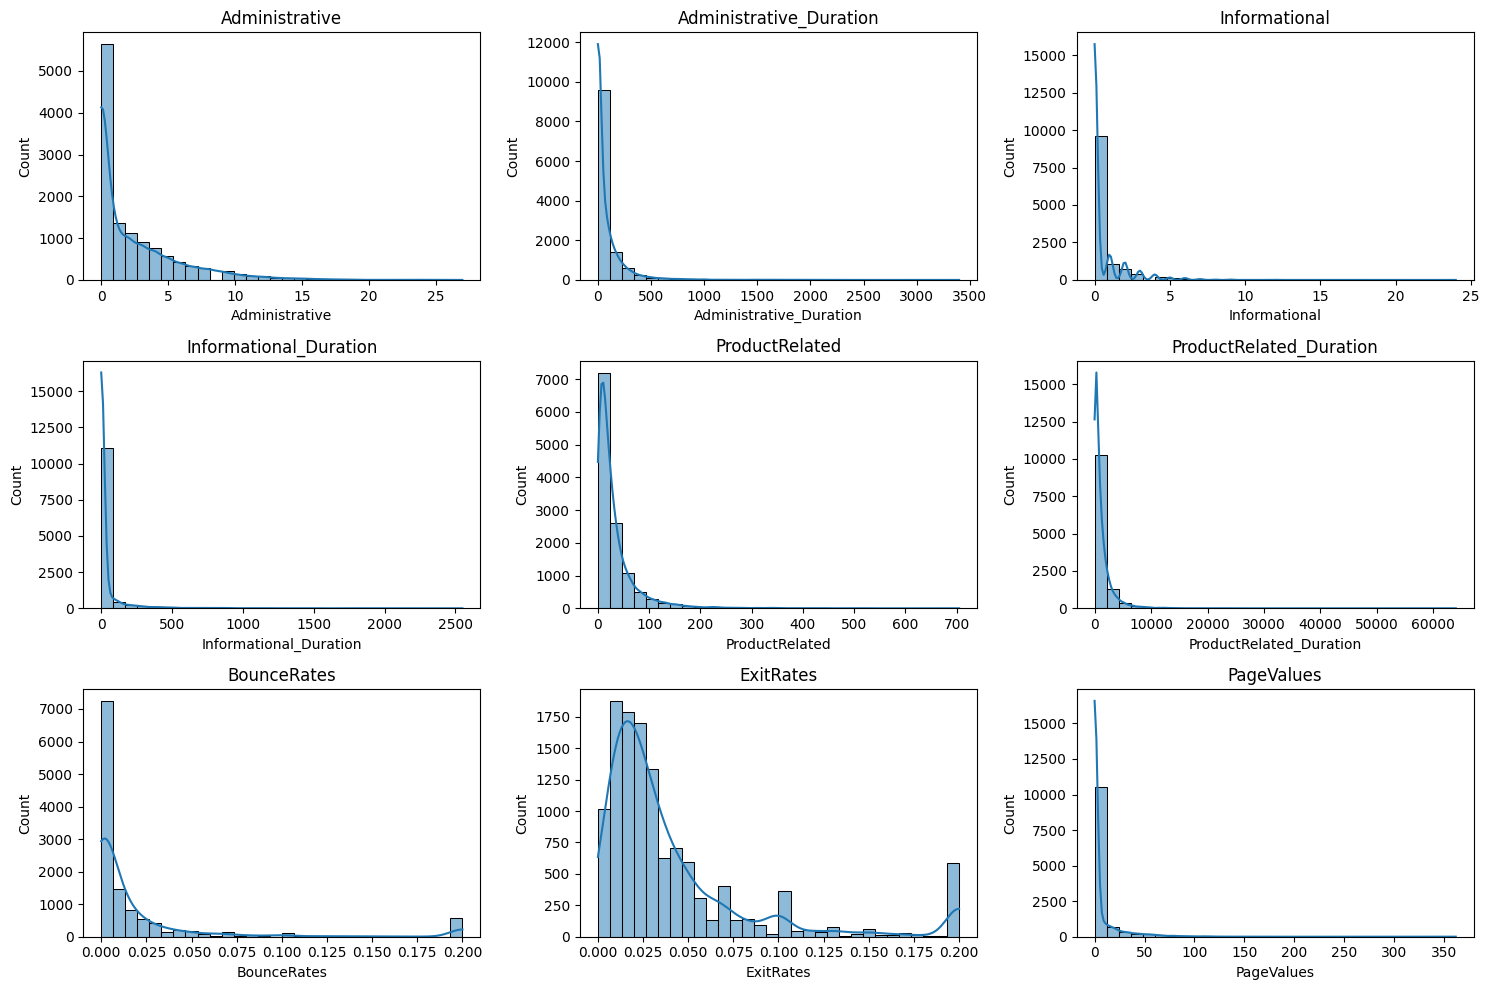

In [98]:
# Univariate Analysis (Numeric Features)

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:9], 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

### Bar Charts

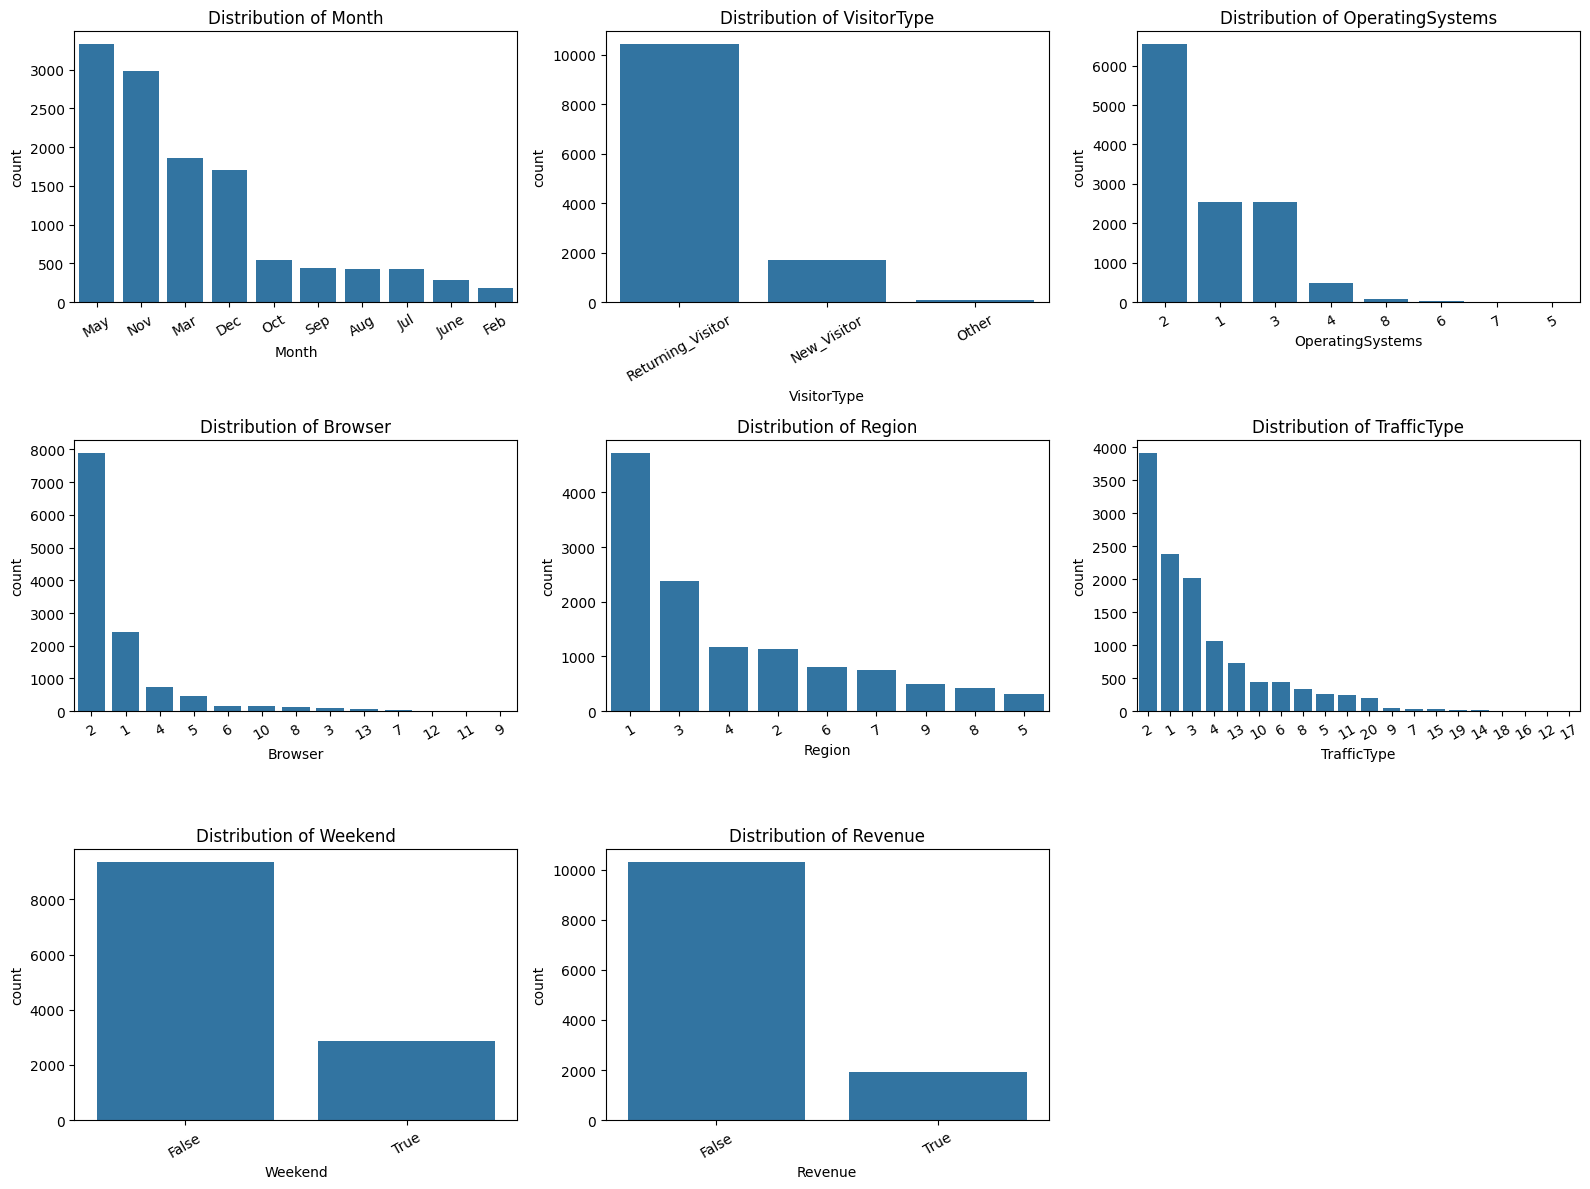

In [99]:
# Categorical Feature Analysis

import math

cat_features = cat_cols + ['Weekend', 'Revenue']

ncols = 3
nrows = math.ceil(len(cat_features) / ncols)

plt.figure(figsize=(16, 4 * nrows))

for i, col in enumerate(cat_features, 1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()

plt.show()

## Bi-variate Analysis

### Stacked Bar Charts

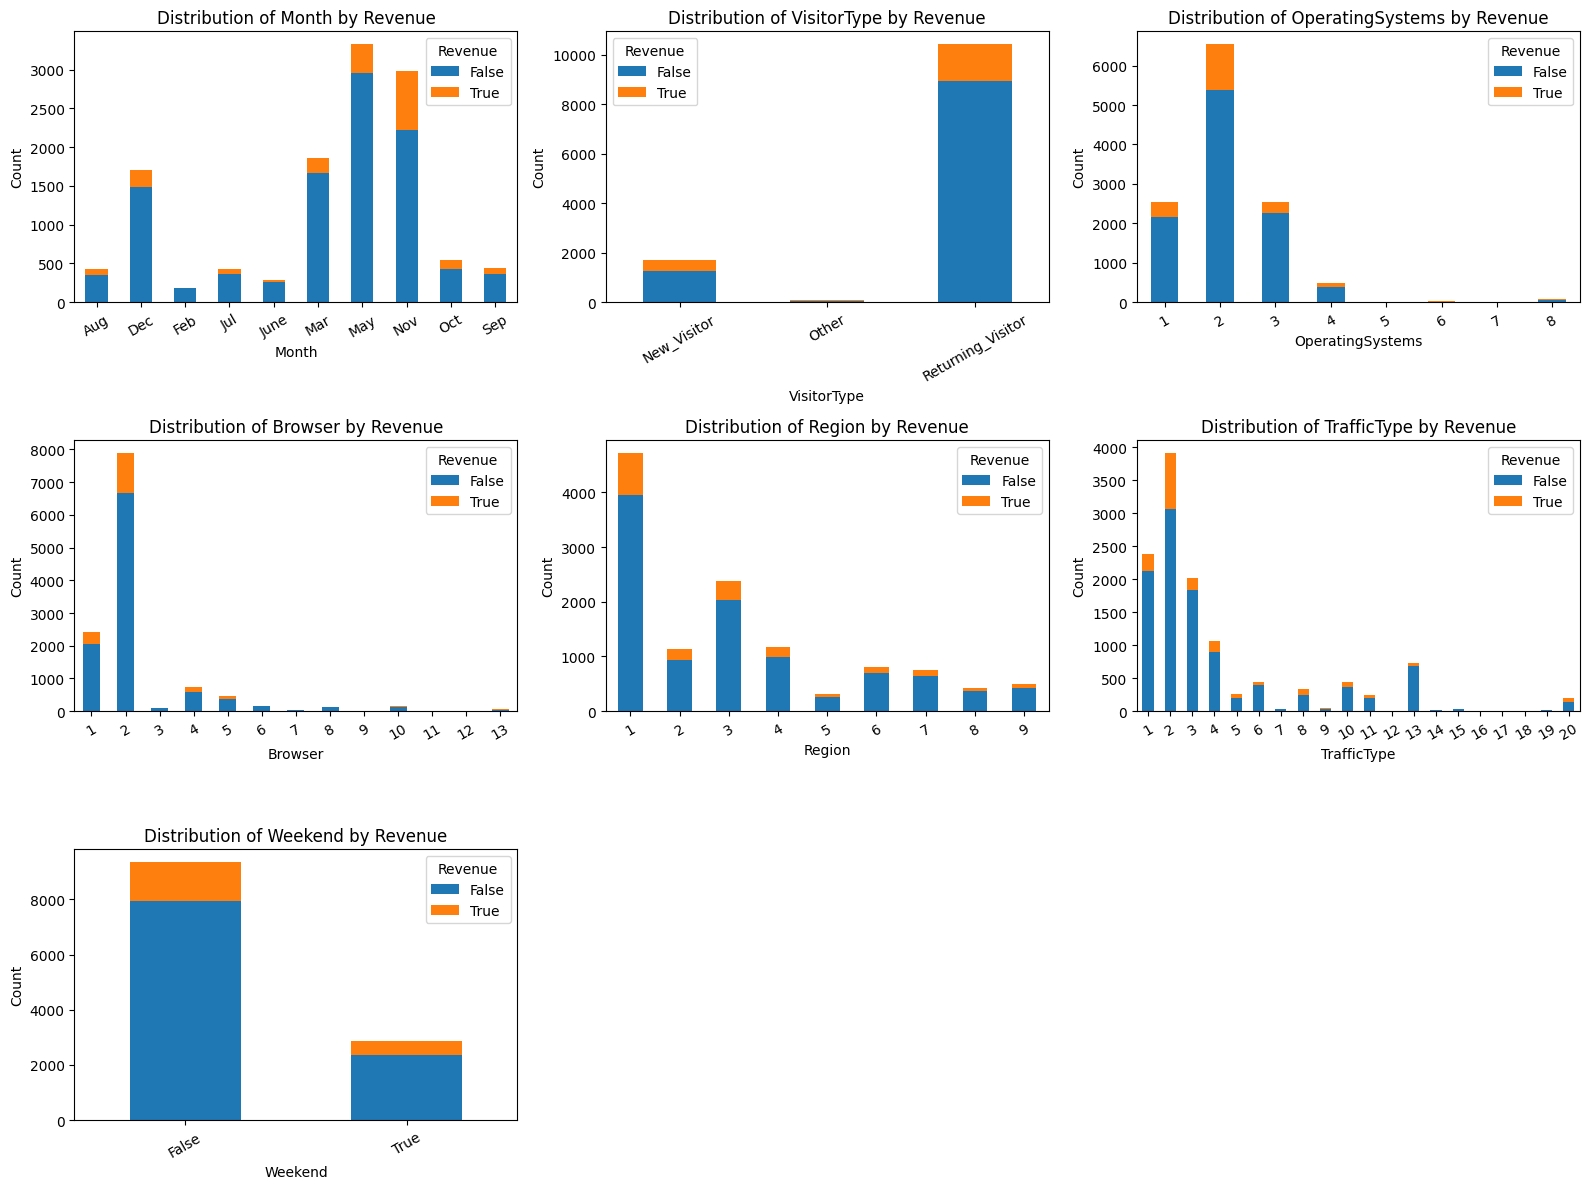

In [100]:

import math
# display stacked bar charts for categorical variables
cat_cols = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

cat_features = cat_cols + ['Weekend']
ncols = 3
nrows = math.ceil(len(cat_features) / ncols)
plt.figure(figsize=(16, 4 * nrows))
# use cross tab
for i, col in enumerate(cat_features, 1):
    ax = plt.subplot(nrows, ncols, i)
    crosstab = pd.crosstab(df[col], df['Revenue'])
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    plt.title(f"Distribution of {col} by Revenue")
    plt.xticks(rotation=30)
    plt.ylabel("Count")
    plt.tight_layout()

plt.show()

### PairPlots

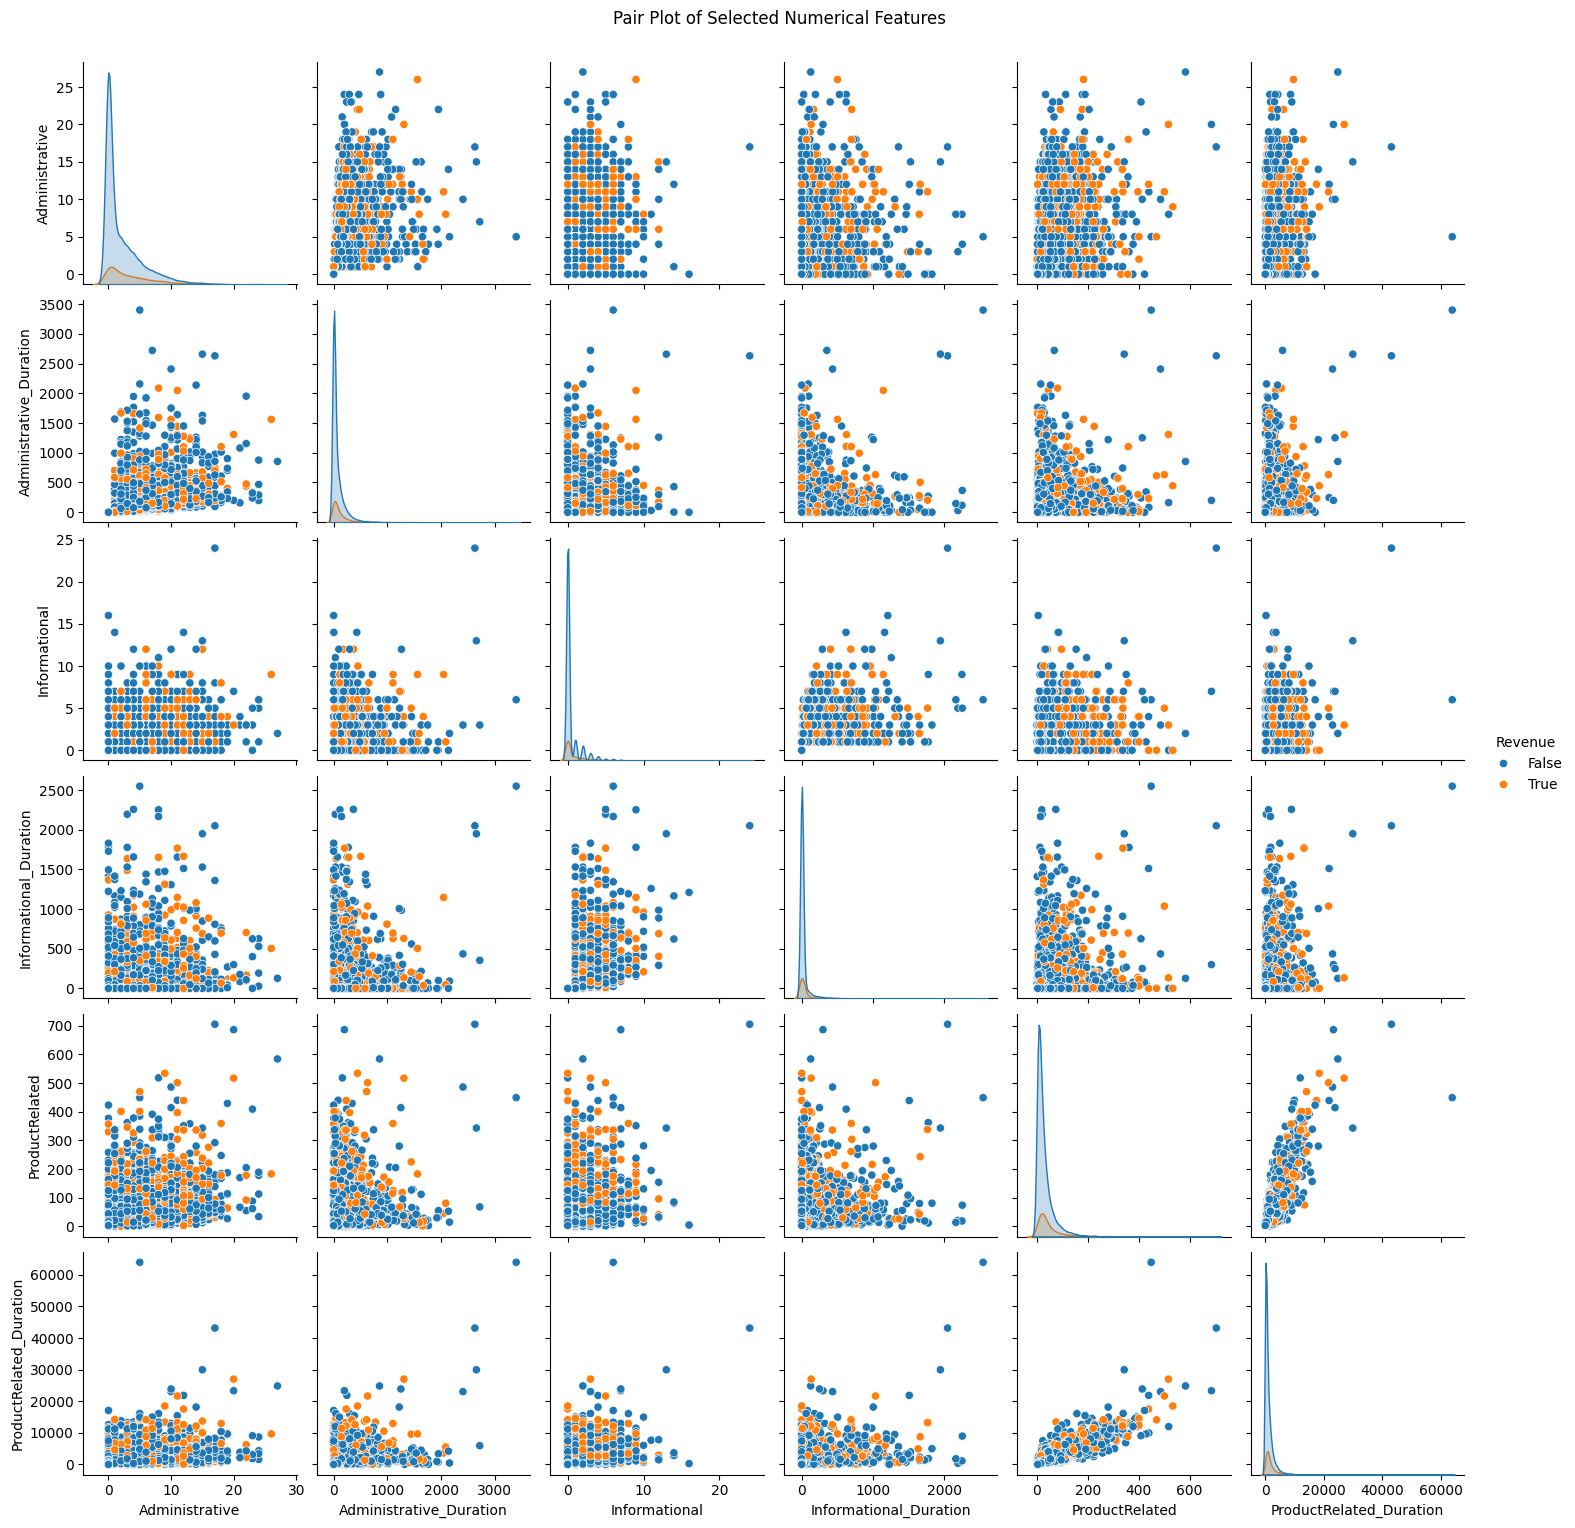

In [101]:
# Display pair plots
subset_numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']

# Revenue as hue
sns.pairplot(df[subset_numerical_cols + ['Revenue']], hue='Revenue')
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

### Box Plots

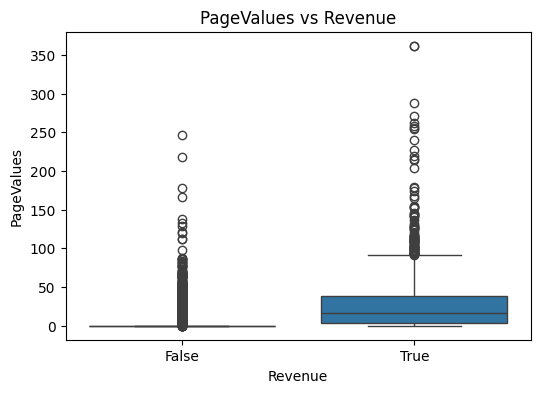

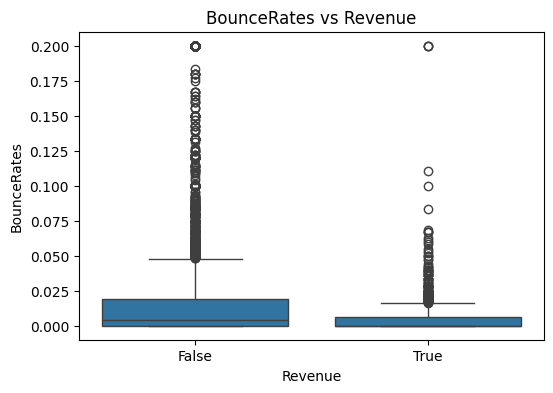

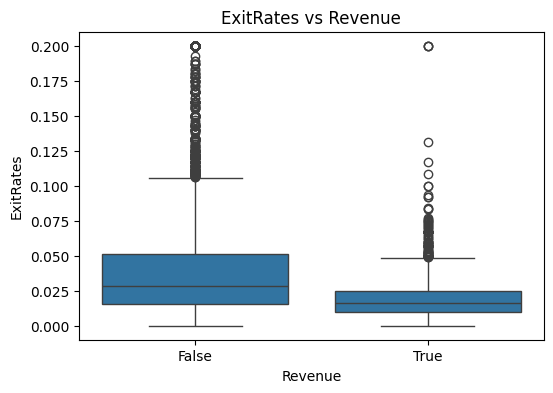

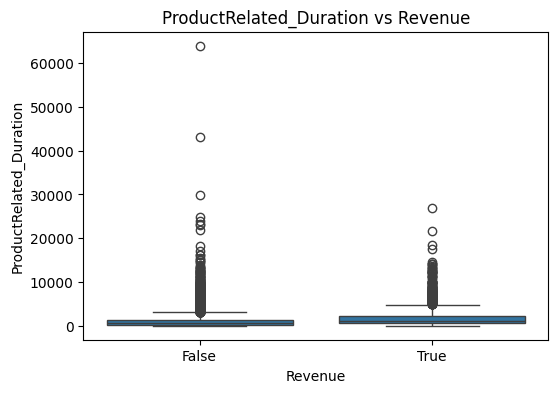

In [102]:
#Box plots to compare side by side comparison by Revenue variable
key_features = ['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated_Duration']

for col in key_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f"{col} vs Revenue")
    plt.show()

### Correlation Matrix

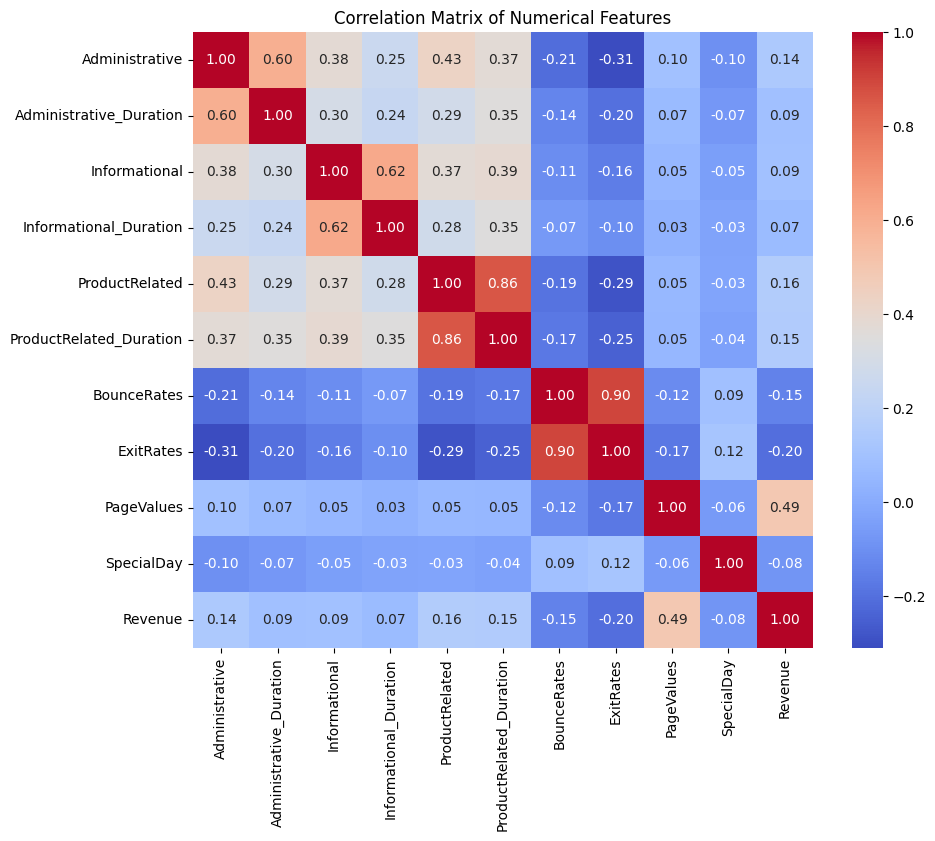

In [103]:

# Create a correlation matrix of the numerical columns
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue']
correlation_matrix = df[numerical_cols].corr()

#  generate correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Correlation with Revenue:
Revenue                    1.000000
PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
Weekend                    0.027729
SpecialDay                -0.083601
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64


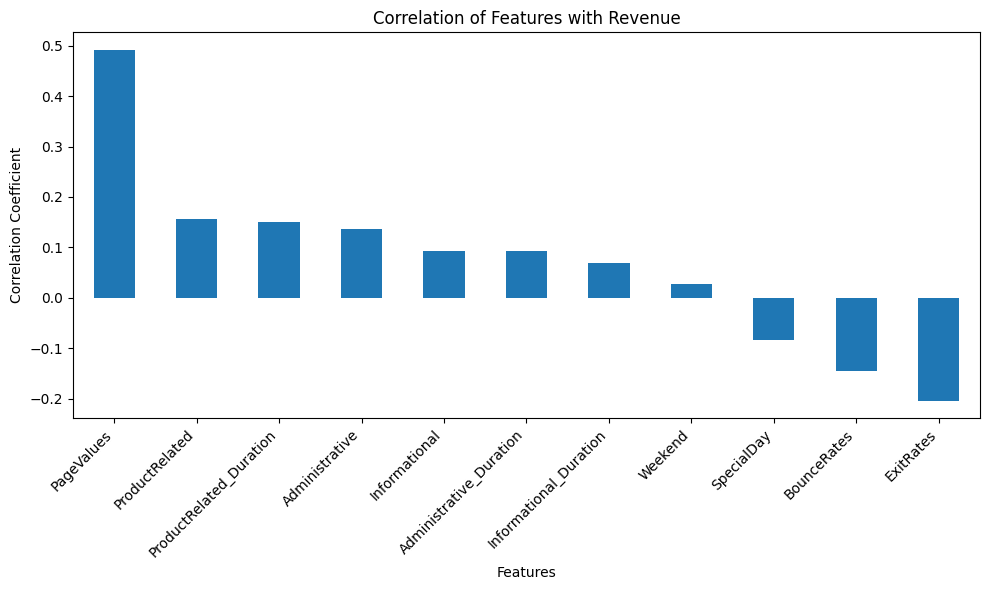

In [104]:
# calculate the correlation matrix
correlation_matrix_combined = df.corr(numeric_only=True)

# get the correlations with the 'Revenue' column
correlation_with_revenue = correlation_matrix_combined['Revenue'].sort_values(ascending=False)

# Display the correlations
print("Correlation with Revenue:")
print(correlation_with_revenue)

# visualize the correlations with a bar plot
plt.figure(figsize=(10, 6))
correlation_with_revenue.drop('Revenue').plot(kind='bar')
plt.title('Correlation of Features with Revenue')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##MultiVariate Analysis

### Mutual Information

Apply Mutual Information to identify the features with the highest relevance to the target variable.

Mutual Information Scores:
PageValues                 0.164394
ExitRates                  0.041262
ProductRelated_Duration    0.032284
ProductRelated             0.021930
BounceRates                0.019264
                             ...   
TrafficType_17             0.000000
TrafficType_19             0.000000
TrafficType_20             0.000000
VisitorType_Other          0.000000
Weekend_True               0.000000
Length: 68, dtype: float64


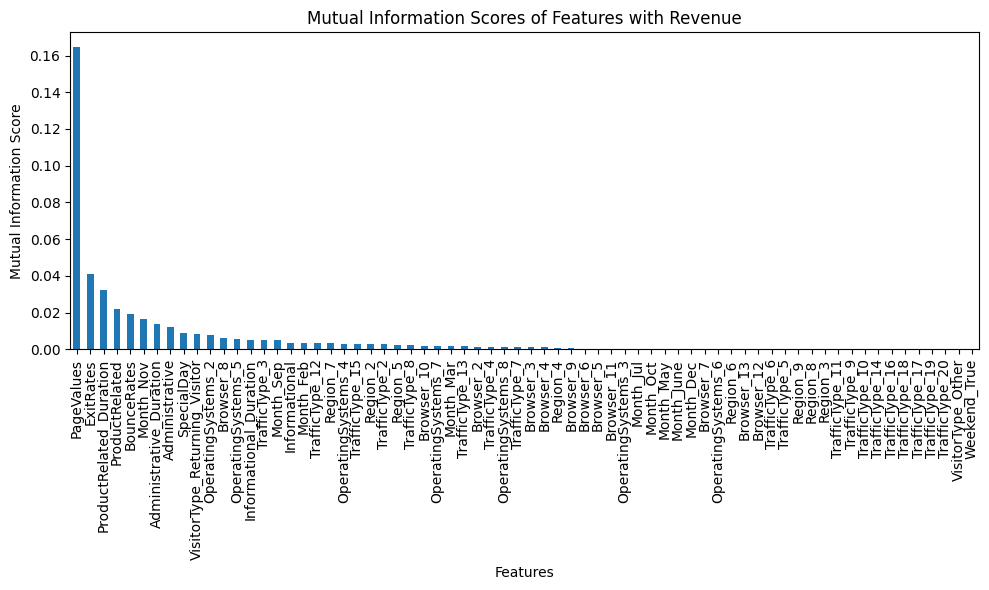

In [105]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import pandas as pd

# Separate features and target for mutual information calculation
features_mutual_info = df.drop('Revenue', axis=1)
target_mutual_info = df['Revenue']

# convert boolean target to integer
target_mutual_info = target_mutual_info.astype(int)

# separate categorical and numerical columns
categorical_cols = features_mutual_info.select_dtypes(include=['object', 'category', 'bool']).columns
numerical_cols = features_mutual_info.select_dtypes(include=np.number).columns

# one-hot encoding to categorical features for mutual information calculation
features_mutual_info_encoded = pd.get_dummies(features_mutual_info, columns=categorical_cols, drop_first=True)

# Calculate mutual information between each feature and the target
mi_scores_raw = mutual_info_classif(features_mutual_info_encoded, target_mutual_info.values.ravel(), random_state=42)
mi_scores_series = pd.Series(mi_scores_raw, index=features_mutual_info_encoded.columns)
mi_scores_sorted = mi_scores_series.sort_values(ascending=False)

# display the mutual information scores
print("Mutual Information Scores:")
print(mi_scores_sorted)

# Plot the mutual info scores
plt.figure(figsize=(10, 6))
mi_scores_sorted.plot(kind='bar')
plt.title('Mutual Information Scores of Features with Revenue')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

###Binomial Regression

In [106]:
import statsmodels.api as sm

# Separate features and target for binomial regression
features_binomial_reg = df.drop('Revenue', axis=1)
target_binomial_reg = df['Revenue'].astype(int)


# numerical columns for binomial regression
numerical_cols_for_br = features_binomial_reg.select_dtypes(include=np.number).columns
features_br_numerical = features_binomial_reg[numerical_cols_for_br]

# Drop columns with zero variance from features_br_numerical to avoid Singular Matrix error
features_br_numerical = features_br_numerical.loc[:, features_br_numerical.var() != 0]

# add a constant for intercept
features_br_with_const = sm.add_constant(features_br_numerical)

# fit the logistic regression model with Logit link since its Binomial usecase
binomial_logit_model = sm.Logit(target_binomial_reg, features_br_with_const)
binomial_reg_result = binomial_logit_model.fit()

# Print the model summary
print(binomial_reg_result.summary())

Optimization terminated successfully.
         Current function value: 0.303936
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                Revenue   No. Observations:                12205
Model:                          Logit   Df Residuals:                    12194
Method:                           MLE   Df Model:                           10
Date:                Thu, 04 Dec 2025   Pseudo R-squ.:                  0.2989
Time:                        20:25:46   Log-Likelihood:                -3709.5
converged:                       True   LL-Null:                       -5291.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.0286      0.071    -28.723      0.000      -2.167   

Lot of show features show p-value less than significant value (0.05) but our objective is to build a model that predicts minority class(revenue=1),so only few features will be considered.

### Principal Component Analysis

Reduce dimensionality and visualize the data in lower dimensions to identify potential clusters or patterns.


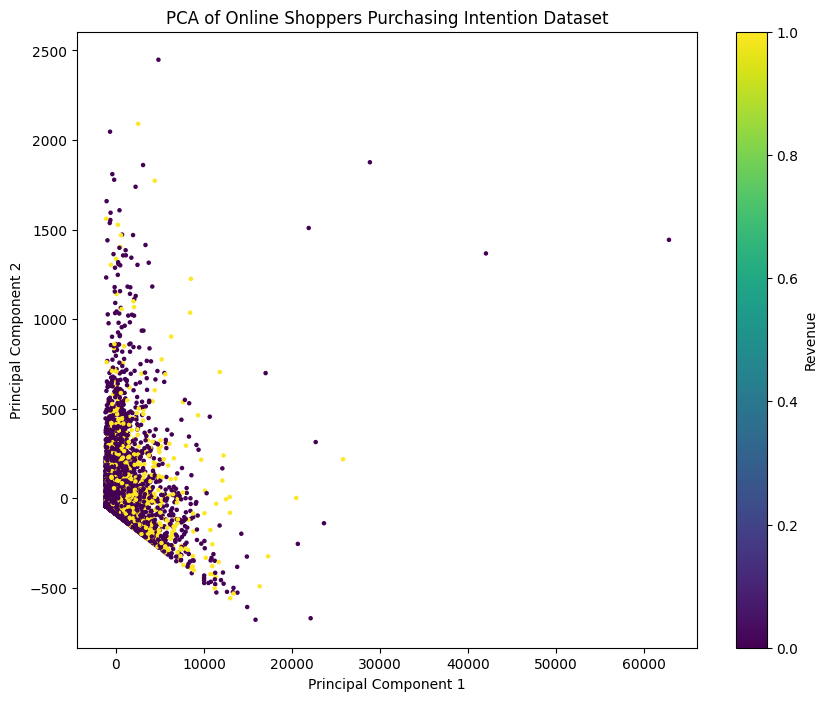

In [107]:
pca = PCA(n_components=3)

# Separate features and target for PCA
X_pca_data = df.drop('Revenue', axis=1)
y_pca_data = df['Revenue'].astype(int)

# Select only numerical columns for PCA
numerical_cols_pca = X_pca_data.select_dtypes(include=np.number).columns
X_pca_numerical = X_pca_data[numerical_cols_pca]


X_pca = pca.fit_transform(X_pca_numerical)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pca_data.values.flatten(), cmap='viridis', s=5)
plt.title('PCA of Online Shoppers Purchasing Intention Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Revenue')
plt.show()

### t-SNE Analysis
t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique that is particularly well-suited for visualizing high-dimensional datasets. Unlike PCA, which focuses on preserving large pairwise distances to maximize variance, t-SNE focuses on preserving local distances,keeping similar data points close together in the low-dimensional space.

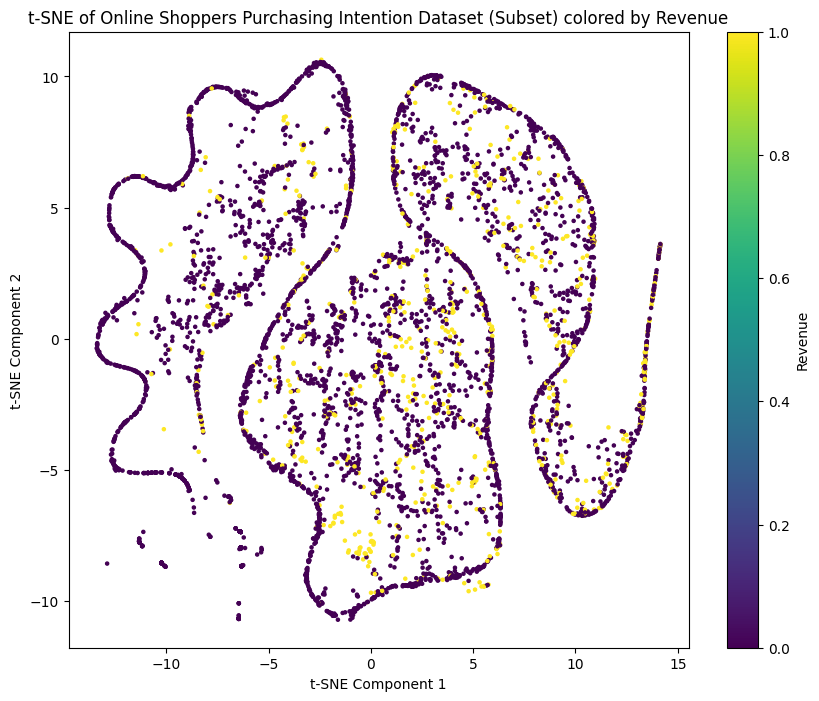

In [108]:
from sklearn.manifold import TSNE

# Apply t-SNE using a small subset
subset_size = 5000


df_subset = df.sample(n=subset_size, random_state=42)

# Separate features and the 'Revenue' column from the subset
X_subset = df_subset.drop('Revenue', axis=1)
revenue_subset = df_subset['Revenue'].astype(int) # Convert boolean target to integer

# Select only numerical columns for t-SNE
numerical_cols_tsne = X_subset.select_dtypes(include=np.number).columns
X_subset_numerical = X_subset[numerical_cols_tsne]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
X_tsne = tsne.fit_transform(X_subset_numerical)

# Visualize t-SNE colored by 'Revenue'
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=revenue_subset, cmap='viridis', s=5)
plt.title('t-SNE of Online Shoppers Purchasing Intention Dataset (Subset) colored by Revenue')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='Revenue')
plt.show()

# Feature Engineering



##Feature Selection
Based on Correlation Analysis and Multi Variate Analysis, We can drop few columns

In [109]:
# Identify the features to keep based on the problem description and potential analysis
features_to_keep = [
    'Administrative',
    'ProductRelated',
    "Informational",
    'BounceRates',
    'ExitRates',
    'PageValues'
]

# Identify columns to drop (those not in features_to_keep and not the target)
all_cols = df.columns.tolist()
cols_to_drop = [col for col in all_cols if col not in features_to_keep and col != 'Revenue']

# Drop the identified columns
df = df.drop(cols_to_drop, axis=1)

In [110]:
df.head()

,Administrative,Informational,ProductRelated,BounceRates,ExitRates,PageValues,Revenue
0,0,0,1,0.20,0.20,0.0,False
1,0,0,2,0.00,0.10,0.0,False
2,0,0,1,0.20,0.20,0.0,False
3,0,0,2,0.05,0.14,0.0,False
4,0,0,10,0.02,0.05,0.0,False


## K clustering to add cluster id to group any sessions

In [111]:
# One-Hot Encoding and Scaling for Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Define features (excluding target)
X_for_clustering = df.drop('Revenue', axis=1)

# Identify numerical and categorical columns
num_cols = X_for_clustering.select_dtypes(include=np.number).columns
cat_cols = X_for_clustering.select_dtypes(include=['object', 'bool', 'category']).columns

print("Numerical columns:", num_cols.tolist())
print("Categorical columns:", cat_cols.tolist())

numeric_pipeline = Pipeline([
    #('imputer', SimpleImputer(strategy='median')), #no missing values identified
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
   # ('imputer', SimpleImputer(strategy='most_frequent')),  #no missing values identified
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Include column names in the transformer tuple
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# Fit and transform
X_prepared = preprocessor.fit_transform(X_for_clustering)

print("Preprocessing complete. Prepared data shape:", X_prepared.shape)


Numerical columns: ['Administrative', 'Informational', 'ProductRelated', 'BounceRates', 'ExitRates', 'PageValues']
Categorical columns: []
Preprocessing complete. Prepared data shape: (12205, 6)


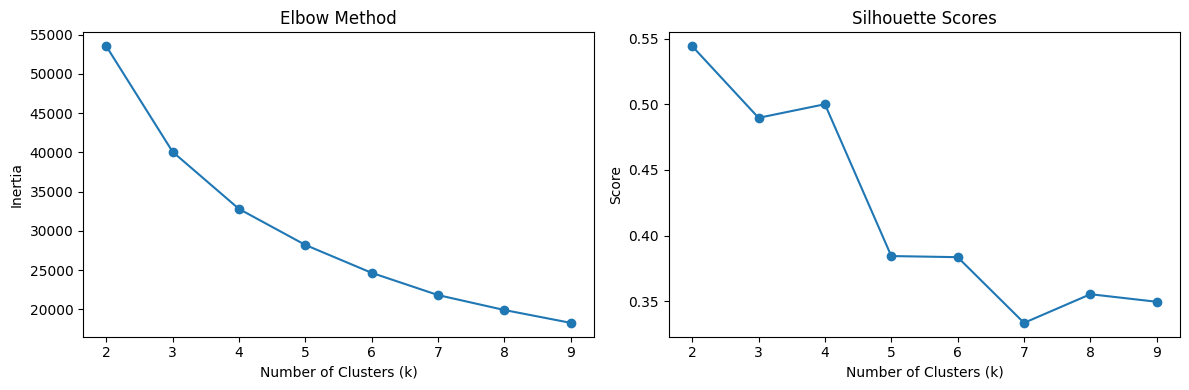

Optimal number of clusters: 2


,Revenue
Cluster_ID,
0,0.168842
1,0.006383


In [112]:
#  K-Means Clustering (Feature Engineering)

inertias, sil_scores = [], []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_prepared)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_prepared, labels))

# Plot elbow and silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# Choose optimal k (highest silhouette)
optimal_k = K_range[np.argmax(sil_scores)]
print("Optimal number of clusters:", optimal_k)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df['Cluster_ID'] = kmeans.fit_predict(X_prepared)
df['Cluster_ID'] = df['Cluster_ID'].astype('category')
df[['Cluster_ID', 'Revenue']].groupby('Cluster_ID')['Revenue'].mean()


### T-SNE component Analysis

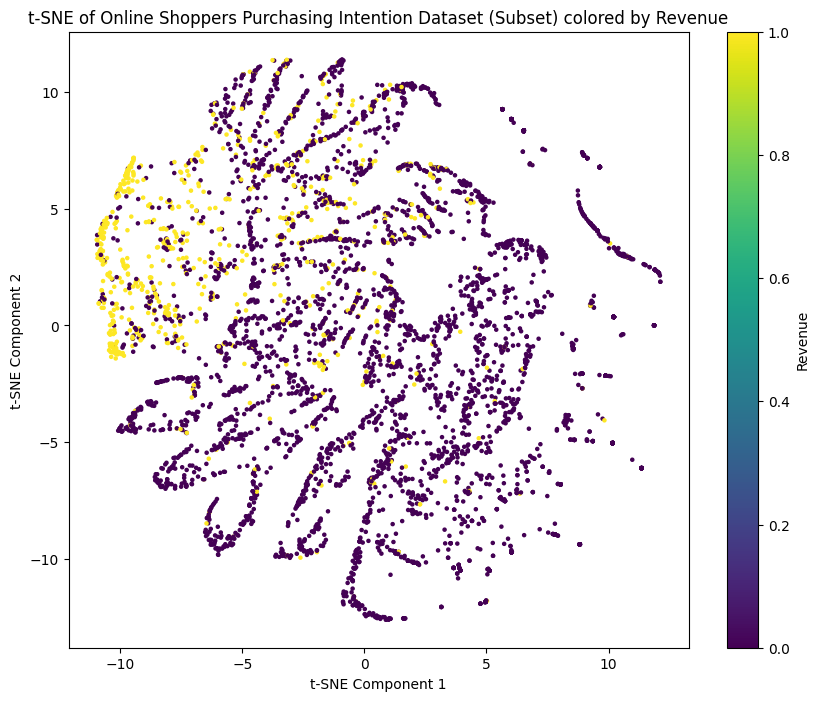

In [113]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Separate features and target
tsne_cluster_features = df.drop(['Revenue'], axis=1)
# We'll also need the Revenue column for coloring the plot
tsne_cluster_target = df['Revenue'].astype(int) # Convert boolean Revenue to integer for coloring

# Identify numerical and categorical columns
tsne_cluster_num_cols = tsne_cluster_features.select_dtypes(include=np.number).columns
tsne_cluster_cat_cols = tsne_cluster_features.select_dtypes(include=['object', 'category', 'bool']).columns

# Scale numerical features
tsne_cluster_scaler = StandardScaler()
tsne_cluster_numerical_scaled = tsne_cluster_scaler.fit_transform(tsne_cluster_features[tsne_cluster_num_cols])
tsne_cluster_numerical_df = pd.DataFrame(tsne_cluster_numerical_scaled, columns=tsne_cluster_num_cols, index=tsne_cluster_features.index)

# One-hot encode categorical features
tsne_cluster_categorical_encoded = pd.get_dummies(tsne_cluster_features[tsne_cluster_cat_cols], columns=tsne_cluster_cat_cols, drop_first=True)


# Concatenate scaled numerical and encoded categorical features for t-SNE
tsne_cluster_processed_features = pd.concat([tsne_cluster_numerical_df, tsne_cluster_categorical_encoded], axis=1)


# Apply t-SNE (using a smaller subset for faster computation and visualization)
subset_size = 5000
if len(tsne_cluster_processed_features) > subset_size:
    tsne_cluster_sample_indices = tsne_cluster_processed_features.sample(n=subset_size, random_state=42).index
    tsne_cluster_sampled_features = tsne_cluster_processed_features.loc[tsne_cluster_sample_indices]
    tsne_cluster_sampled_target = tsne_cluster_target.loc[tsne_cluster_sample_indices] # Get Revenue for the subset
else:
    tsne_cluster_sampled_features = tsne_cluster_processed_features
    tsne_cluster_sampled_target = tsne_cluster_target


tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
tsne_cluster_reduced_data = tsne.fit_transform(tsne_cluster_sampled_features)

# Visualize t-SNE colored by 'Revenue'
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_cluster_reduced_data[:, 0], tsne_cluster_reduced_data[:, 1], c=tsne_cluster_sampled_target, cmap='viridis', s=5)
plt.title('t-SNE of Online Shoppers Purchasing Intention Dataset (Subset) colored by Revenue')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='Revenue') # Corrected label here
plt.show()

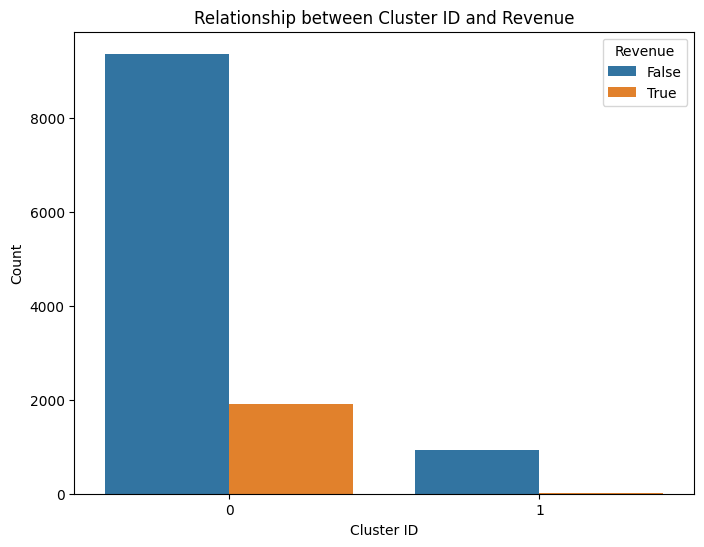

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a count plot of Cluster_ID by Revenue
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Cluster_ID', hue='Revenue')
plt.title('Relationship between Cluster ID and Revenue')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.show()


# Train , Test, Validation Data Preparation


Prepare the data for model building by separating features and target, handling categorical variables, and splitting the data into training and testing sets.

## Scaling and One-hot Encoding

Scale the numerical variables and one hot encode categorical variables.


In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np


X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=np.number).columns

# Define categorical columns for encoding
cat_cols = [ 'Cluster_ID']

print("Final List of Numerical columns:", num_cols.tolist())
print("Final List of Categorical columns:", cat_cols)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
   # ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Include column names in the transformer tuple
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# Fit and transform
X_prepared = preprocessor.fit_transform(X)


Final List of Numerical columns: ['Administrative', 'Informational', 'ProductRelated', 'BounceRates', 'ExitRates', 'PageValues']
Final List of Categorical columns: ['Cluster_ID']


In [116]:
# Reconstruct data frame along with cols for feature importance
# Optimizing code - avoid multiple encoding and scaling
# Get the feature names for numerical columns (scaled)
scaled_feature_names = num_cols

# Get the feature names for one-hot encoded categorical columns
# Access the OneHotEncoder from the preprocessor
categorical_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
encoded_feature_names = categorical_encoder.get_feature_names_out(cat_cols)

# Combine all feature names
all_feature_names = list(scaled_feature_names) + list(encoded_feature_names)

# Create the DataFrame
X_processed_df = pd.DataFrame(X_prepared, columns=all_feature_names)

print("Shape of the processed DataFrame after scaling and encoding:", X_processed_df.shape)
display(X_processed_df.head())

Shape of the processed DataFrame after scaling and encoding: (12205, 7)


,Administrative,Informational,ProductRelated,BounceRates,ExitRates,PageValues,Cluster_ID_1
0,-0.702302,-0.398824,-0.696218,3.969402,3.434394,-0.318962,1.0
1,-0.702302,-0.398824,-0.673793,-0.450137,1.268054,-0.318962,0.0
2,-0.702302,-0.398824,-0.696218,3.969402,3.434394,-0.318962,1.0
3,-0.702302,-0.398824,-0.673793,0.654748,2.134590,-0.318962,1.0
4,-0.702302,-0.398824,-0.494387,-0.008183,0.184884,-0.318962,0.0


## Split the data

Split the dataset into training and testing sets.


In [117]:
from sklearn.model_selection import train_test_split
# Use scaled , encoded and reconstructed df earlier
# Split the data into training (80%), validation (10%), and testing (10%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X_processed_df, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (9764, 7)
Shape of X_val: (1220, 7)
Shape of X_test: (1221, 7)
Shape of y_train: (9764,)
Shape of y_val: (1220,)
Shape of y_test: (1221,)


## SMOTE for  class imbalance

Apply SMOTE to the training data to address the class imbalance in the Diabetes_binary variable.


In [118]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of original X_train:", X_train.shape)
print("Shape of resampled X_train:", X_train_resampled.shape)
print("Shape of original y_train:", y_train.shape)
print("Shape of resampled y_train:", y_train_resampled.shape)

Shape of original X_train: (9764, 7)
Shape of resampled X_train: (16476, 7)
Shape of original y_train: (9764,)
Shape of resampled y_train: (16476,)


#Model Training and Validation


A group of models are chosen based on the usecase and trained with Hyperparameter tuning and then a model ensemble is created to predict target variable (Revenue=True) following Mixture of Experts of pattern.


## Model Selection And Parameters

In [119]:
from random import randint
from scipy.stats import loguniform
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, recall_score, balanced_accuracy_score, roc_auc_score

# Linear Models
from sklearn.linear_model import LogisticRegression

# Tree-Based Models
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting Model
from xgboost import XGBClassifier

# Neural Network Model
from sklearn.neural_network import MLPClassifier

# SVM model
from sklearn.svm import SVC

# model list and params
models_and_params = [
    {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2']
        }
    },
    {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [200, 300, 500],
            'max_depth': [10, 20,30],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': ['balanced', 'balanced_subsample']
        }
     }
    ,

    {
        'model': XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        'params': {
            'n_estimators': [200, 300],
            'learning_rate': [0.5, 0.1,0.05],
            'max_depth': [5, 7, 9],
            'gamma': [0, 0.1, 0.2],
            'reg_alpha': [0, 0.1, 0.5],
            'reg_lambda': [1, 1.5, 2]
        }

     }
    ,

     {
        'model': MLPClassifier(
             solver='adam',
             activation='relu',
             max_iter=500,
             random_state=42,
             early_stopping=True,
             validation_fraction=0.1,
             n_iter_no_change=20
        ),
        'params': {
            "hidden_layer_sizes": [(64, 32)],
            "activation": ["relu"],
            "alpha": [1e-1],
            "learning_rate_init": [1e-2],
            "batch_size": [256, 512],
        }
    },
    {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    }
]

## Training and Hyperparameter Tuning using GridSearch

In [120]:
#Use GridSearchCV on Each Model for hyper parameter tuning
results = []
best_estimator = None
best_f1 = 0.0
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Starting comprehensive Grid Search for all 5 models using Stratified K-Fold...")

# Use the resampled data for training GridSearch
X_train_gs = X_train_resampled
y_train_gs = y_train_resampled

for item in models_and_params:
    model = item['model']
    params = item['params']
    model_name = model.__class__.__name__

    print(f"Running Grid Search for {model_name}...")


    #  Hyperparamter scoring set to f1 for imbalanced data classes
    grid_search = GridSearchCV(estimator=model, param_grid=params, cv=stratified_kfold, n_jobs=-1, scoring='f1', verbose=0)
    grid_search.fit(X_train_gs, y_train_gs)

    # Evaluate on the test set (using the correctly encoded and aligned test set)
    y_pred_test = grid_search.best_estimator_.predict(X_test)
    y_pred_proba_test = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

    # Calculate metrics on the test set
    test_accuracy = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test)
    balanced_acc_test = balanced_accuracy_score(y_test, y_pred_test)
    auc_test = roc_auc_score(y_test, y_pred_proba_test)


    results.append({
        'Model': model_name,
        'Best CV Score': grid_search.best_score_,
        'Test Accuracy': test_accuracy,
        'F1 Score': f1_test,
        'Recall': recall_test,
        'Precision': precision_test,
        'Balanced Accuracy': balanced_acc_test,
        'AUC': auc_test,
        'Best Parameters': grid_search.best_params_
    })

    # Not required but just in case. Update best_estimator based on F1 score on the test set
    if f1_test > best_f1:
        best_f1 = f1_test
        best_estimator = grid_search.best_estimator_

    print(f"Finished Grid Search for {model_name}.")

Starting comprehensive Grid Search for all 5 models using Stratified K-Fold...
Running Grid Search for LogisticRegression...
Finished Grid Search for LogisticRegression.
Running Grid Search for RandomForestClassifier...
Finished Grid Search for RandomForestClassifier.
Running Grid Search for XGBClassifier...
Finished Grid Search for XGBClassifier.
Running Grid Search for MLPClassifier...
Finished Grid Search for MLPClassifier.
Running Grid Search for SVC...
Finished Grid Search for SVC.


## Individual Model Test Metrics

In [121]:
#Calculating Test Metrics now
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, balanced_accuracy_score, f1_score, recall_score, precision_score

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True) # Sort by F1 Score
pd.set_option('display.max_colwidth', None)

print("\n--- Final Comprehensive Results ---")
print(results_df)



--- Final Comprehensive Results ---
                    Model  Best CV Score  Test Accuracy  F1 Score    Recall  \
0      LogisticRegression       0.804379       0.882064  0.675676  0.785340   
1  RandomForestClassifier       0.907871       0.881245  0.668192  0.764398   
2                     SVC       0.834831       0.876331  0.665188  0.785340   
3           MLPClassifier       0.856934       0.864046  0.658436  0.837696   
4           XGBClassifier       0.918904       0.883702  0.657005  0.712042   

   Precision  Balanced Accuracy       AUC  \
0   0.592885           0.842670  0.903266   
1   0.593496           0.833655  0.918058   
2   0.576923           0.839272  0.894340   
3   0.542373           0.853314  0.923598   
4   0.609865           0.813788  0.892825   

                                                                                                       Best Parameters  
0                                                                                         {'C': 

## Model Ensemble and Voting Classifier
 Voting Classifier with the best performing models from the Grid Search.


In [122]:
from sklearn.ensemble import VotingClassifier
import pandas as pd # Import pandas

# Get the best estimators from the grid search results and ensure they are refitted if necessary
best_estimators_list = []
for result in results:
    model_name = result['Model']
    best_params = result['Best Parameters']

    # Reinstantiate the model with the best parameters
    if model_name == 'LogisticRegression':
        model = LogisticRegression(**best_params, max_iter=1000, solver='liblinear')
    elif model_name == 'RandomForestClassifier':
        model = RandomForestClassifier(**best_params)
    elif model_name == 'XGBClassifier':
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
    elif model_name == 'MLPClassifier':
        model = MLPClassifier(**best_params, max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=20)
    elif model_name == 'SVC':
        model = SVC(**best_params,probability=True, random_state=42)
    else:
        continue # Skip if the model is not one of the defined types

    best_estimators_list.append((model_name, model))


# Define the Voting Classifier
# 'soft' voting uses predicted probabilities
voting_clf = VotingClassifier(estimators=best_estimators_list, voting='soft')
voting_clf.fit(X_train_resampled, y_train_resampled)
print("Voting Classifier training completed!")

Voting Classifier training completed!


## Model Ensemble Test Data Comparison

Compare the performance of the Voting Classifier to the individual models based on key evaluation metrics.

In [123]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, balanced_accuracy_score, f1_score, recall_score, precision_score
import pandas as pd
import numpy as np

# Create a list of all models to evaluate on the test data
models_to_evaluate_test = []

# Add individual best estimators
for result in results:
    model_name = result['Model']
    # We need the actual fitted estimator, which was stored as best_estimator in the GridSearchCV step
    # Reconstruct the model with best parameters if it's not the best_estimator overall
    if result['Model'] == best_estimator.__class__.__name__:
        models_to_evaluate_test.append((model_name, best_estimator))
    else:
        # Find the specific best estimator for this model type from the results list
        for item in models_and_params:
            if item['model'].__class__.__name__ == model_name:
                # Reinstantiate the model with the stored best_params if necessary
                # This is a bit redundant if grid_search.best_estimator_ was saved, but safe
                if model_name == 'LogisticRegression':
                    model_instance = LogisticRegression(**result['Best Parameters'], max_iter=1000, solver='liblinear')
                elif model_name == 'RandomForestClassifier':
                    model_instance = RandomForestClassifier(**result['Best Parameters'])
                elif model_name == 'XGBClassifier':
                    model_instance = XGBClassifier(**result['Best Parameters'], use_label_encoder=False, eval_metric='logloss')
                elif model_name == 'MLPClassifier':
                    model_instance = MLPClassifier(**result['Best Parameters'], max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=20)
                elif model_name == 'SVC':
                    model_instance = SVC(**result['Best Parameters'], probability=True, random_state=42)
                else:
                    continue
                # Re-fit the model (this will use the best params for the specific model type)
                model_instance.fit(X_train_resampled, y_train_resampled)
                models_to_evaluate_test.append((model_name, model_instance))
                break

# Add the Voting Classifier itself
models_to_evaluate_test.append(('Voting Classifier', voting_clf))


test_results_per_class = []
pd.set_option('display.max_colwidth', None)

for model_name, model in models_to_evaluate_test:
    y_pred_test_current = model.predict(X_test)

    # Handle predict_proba for models that might not have it (e.g., some SVC setups)
    if hasattr(model, 'predict_proba'):
        y_pred_proba_test_current = model.predict_proba(X_test)[:, 1]
    else:
        # Placeholder if no probabilities can be obtained
        y_pred_proba_test_current = np.array([0.5] * len(y_test))

    # Generate classification report in dictionary format
    report = classification_report(y_test, y_pred_test_current, output_dict=True)

    # Extract metrics for 'False' and 'True' classes
    false_class_metrics = report['False']
    true_class_metrics = report['True']
    overall_accuracy = report['accuracy']
    overall_f1 = f1_score(y_test, y_pred_test_current)
    overall_recall = recall_score(y_test, y_pred_test_current)
    overall_precision = precision_score(y_test, y_pred_test_current)
    overall_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_test_current)
    overall_auc = roc_auc_score(y_test, y_pred_proba_test_current) if hasattr(model, 'predict_proba') else np.nan

    test_results_per_class.append({
        'Model': model_name,
        'F1 Score (Overall)': overall_f1,
        'Recall (Overall)': overall_recall,
        'Precision (Overall)': overall_precision,
        'Balanced Accuracy': overall_balanced_accuracy,
        'AUC': overall_auc,
        'Accuracy (Overall)': overall_accuracy,
        'F1 Score (False)': false_class_metrics['f1-score'],
        'Recall (False)': false_class_metrics['recall'],
        'Precision (False)': false_class_metrics['precision'],
        'F1 Score (True)': true_class_metrics['f1-score'],
        'Recall (True)': true_class_metrics['recall'],
        'Precision (True)': true_class_metrics['precision']
    })

# Convert the list into a pandas DataFrame
test_comparison_df = pd.DataFrame(test_results_per_class)

print("\n--- Comparison of Model Performance on Test Data ---")
display(test_comparison_df.sort_values(by='F1 Score (Overall)', ascending=False).reset_index(drop=True))


--- Comparison of Model Performance on Test Data ---


,Model,F1 Score (Overall),Recall (Overall),Precision (Overall),Balanced Accuracy,AUC,Accuracy (Overall),F1 Score (False),Recall (False),Precision (False),F1 Score (True),Recall (True),Precision (True)
0,LogisticRegression,0.675676,0.785340,0.592885,0.842670,0.903266,0.882064,0.927928,0.900000,0.957645,0.675676,0.785340,0.592885
1,RandomForestClassifier,0.671264,0.764398,0.598361,0.834626,0.918124,0.882883,0.928749,0.904854,0.953941,0.671264,0.764398,0.598361
2,Voting Classifier,0.669683,0.774869,0.589641,0.837435,0.925444,0.880426,0.927000,0.900000,0.955670,0.669683,0.774869,0.589641
3,SVC,0.665188,0.785340,0.576923,0.839272,0.894340,0.876331,0.924159,0.893204,0.957336,0.665188,0.785340,0.576923
4,MLPClassifier,0.658436,0.837696,0.542373,0.853314,0.923598,0.864046,0.915133,0.868932,0.966523,0.658436,0.837696,0.542373
5,XGBClassifier,0.657005,0.712042,0.609865,0.813788,0.892825,0.883702,0.929980,0.915534,0.944890,0.657005,0.712042,0.609865


**Individual Model Performance**

Each individual model brought distinct strengths to the ensemble, as observed on the test set:

*  **Logistic Regression:** Achieved the highest F1 Score (0.67) among individual models and strong Recall (0.78). Its simplicity and interpretability provided a solid baseline.
*   **RandomForestClassifier:** Exhibited a very strong AUC (0.92), second only to MLPClassifier, indicating excellent discriminative power. Its F1 Score (0.66) and recall (0.76) were competitive.
*   **SVC (Support Vector Classifier):** Showed a high Recall (0.78), similar to Logistic Regression, but had the lowest AUC (0.89), suggesting weaker overall discriminative ability across thresholds.
*  **MLPClassifier (Multilayer Perceptron):** Stood out with the highest Recall (0.83) and the highest AUC (0.92), signifying its excellent ability to identify positive cases and discriminate between classes. However, its F1 Score (0.65) was slightly lower than Logistic Regression, indicating a trade-off with precision.
*  **XGBClassifier:** While a powerful algorithm, it recorded the lowest F1 Score (0.65) and Recall (0.71) among the evaluated models on this specific dataset, though its AUC was respectable (0.89).



## Model Ensemble Validation and Accuracy Metrics


--- Model Performance on Validation Data ---


,Model,F1 Score (Overall),Recall (Overall),Precision (Overall),Balanced Accuracy,AUC,Accuracy (Overall),F1 Score (False),Recall (False),Precision (False),F1 Score (True),Recall (True),Precision (True)
0,Voting Classifier,0.660714,0.774869,0.575875,0.834471,0.889203,0.875410,0.923695,0.894072,0.955348,0.660714,0.774869,0.575875
1,MLPClassifier,0.643863,0.837696,0.522876,0.847906,0.888002,0.854918,0.908904,0.858115,0.966083,0.643863,0.837696,0.522876
2,SVC,0.638950,0.764398,0.548872,0.823890,0.857560,0.864754,0.916793,0.883382,0.952830,0.638950,0.764398,0.548872
3,LogisticRegression,0.637615,0.727749,0.567347,0.812368,0.880606,0.870492,0.921158,0.896987,0.946667,0.637615,0.727749,0.567347
4,RandomForestClassifier,0.632054,0.732984,0.555556,0.812070,0.879563,0.866393,0.918378,0.891156,0.947314,0.632054,0.732984,0.555556
5,XGBClassifier,0.604762,0.664921,0.554585,0.782898,0.851714,0.863934,0.917822,0.900875,0.935419,0.604762,0.664921,0.554585



--- Voting Classifier Metrics on Validation Data ---
F1 Score: 0.66
Recall: 0.77
Precision: 0.58
Balanced Accuracy: 0.83
AUC: 0.89
Accuracy: 0.88

Classification Report on Validation Data:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      1029
        True       0.58      0.77      0.66       191

    accuracy                           0.88      1220
   macro avg       0.77      0.83      0.79      1220
weighted avg       0.90      0.88      0.88      1220



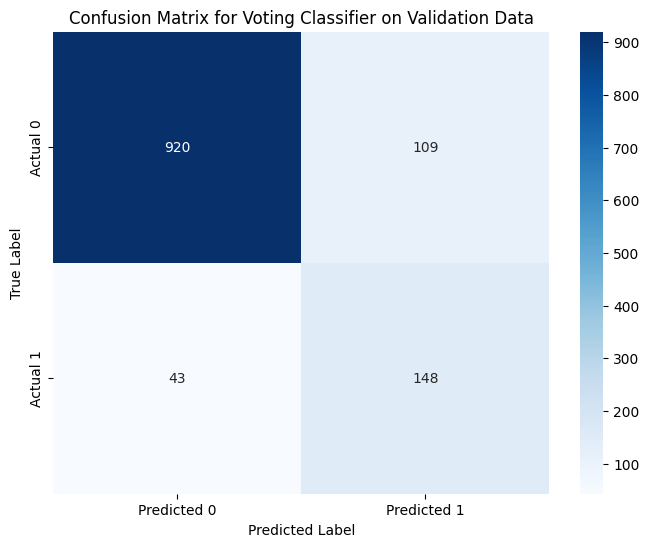

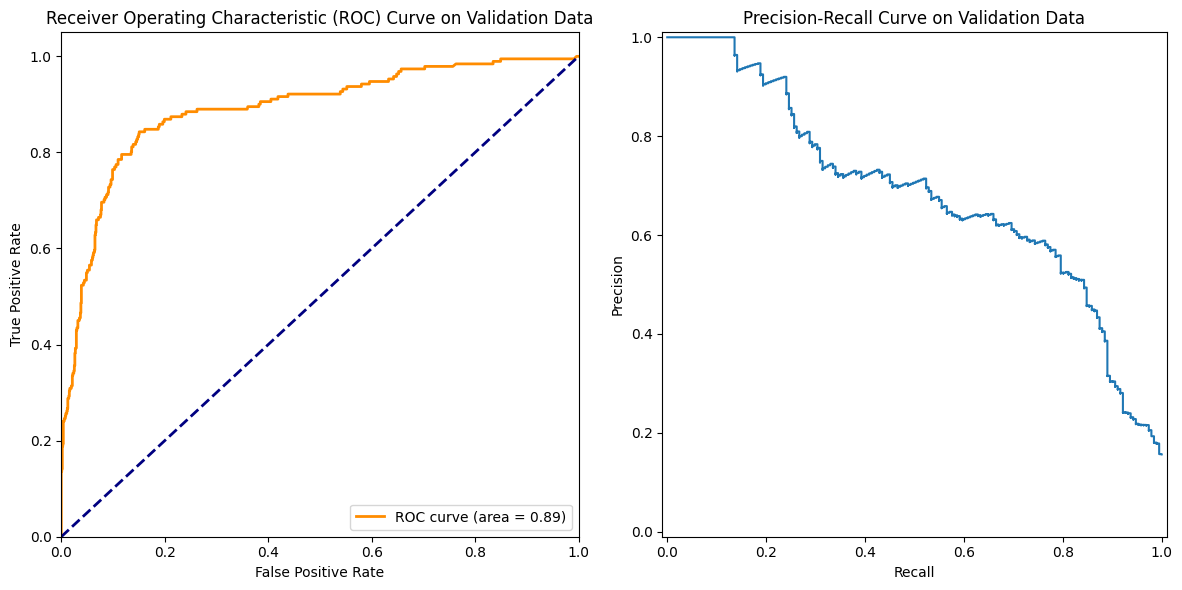


AUC for the Voting Classifier on Validation Data: 0.89


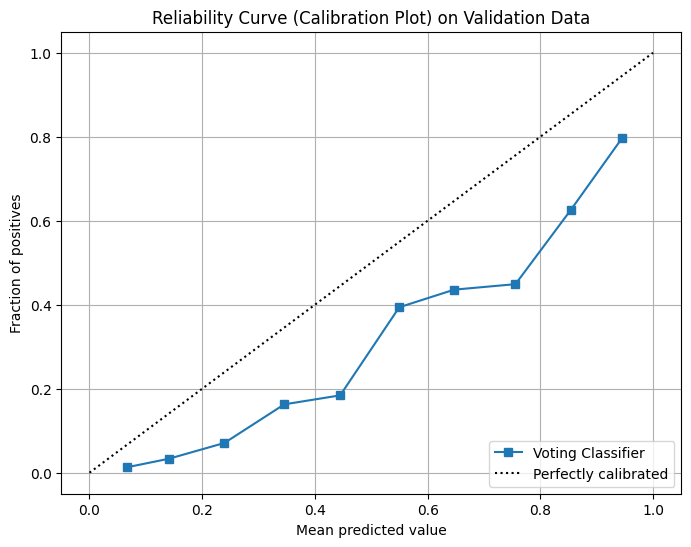

In [124]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, balanced_accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, PrecisionRecallDisplay, auc
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# List to store models to evaluate (individual best estimators + Voting Classifier)
models_to_evaluate = []

# Add fitted sub-estimators from VotingClassifier
#voting_clf is already fitted
if hasattr(voting_clf, 'estimators_'):
    for (name, _), fitted_model in zip(voting_clf.estimators, voting_clf.estimators_):
        models_to_evaluate.append((name, fitted_model))

models_to_evaluate.append(('Voting Classifier', voting_clf))

validation_results = []

for name, model in models_to_evaluate:
    y_pred_val = model.predict(X_val)
    if hasattr(model, 'predict_proba'):
        y_pred_proba_val = model.predict_proba(X_val)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred_proba_val)
    else:
        y_pred_proba_val = np.array([0.5] * len(y_val))
        auc_score = np.nan

    f1 = f1_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    balanced_acc = balanced_accuracy_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)

    # Generate classification report for per-class metrics
    report_val = classification_report(y_val, y_pred_val, output_dict=True)
    f1_false = report_val['False']['f1-score']
    recall_false = report_val['False']['recall']
    precision_false = report_val['False']['precision']
    f1_true = report_val['True']['f1-score']
    recall_true = report_val['True']['recall']
    precision_true = report_val['True']['precision']


    validation_results.append({
        'Model': name,
        'F1 Score (Overall)': f1,
        'Recall (Overall)': recall,
        'Precision (Overall)': precision,
        'Balanced Accuracy': balanced_acc,
        'AUC': auc_score,
        'Accuracy (Overall)': accuracy,
        'F1 Score (False)': f1_false,
        'Recall (False)': recall_false,
        'Precision (False)': precision_false,
        'F1 Score (True)': f1_true,
        'Recall (True)': recall_true,
        'Precision (True)': precision_true
    })

validation_df = pd.DataFrame(validation_results)

print("\n--- Model Performance on Validation Data ---")
display(validation_df.sort_values(by='F1 Score (Overall)', ascending=False).reset_index(drop=True))



# Evaluate the Voting Classifier on the validation set
y_pred_val = voting_clf.predict(X_val)
y_pred_proba_val = voting_clf.predict_proba(X_val)[:, 1]

print("\n--- Voting Classifier Metrics on Validation Data ---")
print(f"F1 Score: {f1_score(y_val, y_pred_val):.2f}")
print(f"Recall: {recall_score(y_val, y_pred_val):.2f}")
print(f"Precision: {precision_score(y_val, y_pred_val):.2f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_val):.2f}")
print(f"AUC: {roc_auc_score(y_val, y_pred_proba_val):.2f}")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.2f}")

print("\nClassification Report on Validation Data:")
print(classification_report(y_val, y_pred_val))

# Confusion Matrix
cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Voting Classifier on Validation Data')
plt.show()

# ROC Curve
fpr_val, tpr_val, _ = roc_curve(y_val, y_pred_proba_val)
roc_auc_val = auc(fpr_val, tpr_val)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_val)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Data')
plt.legend(loc="lower right")

# Precision-Recall Curve
precision_val, recall_val, _ = precision_recall_curve(y_val, y_pred_proba_val)

plt.subplot(1, 2, 2)
disp_val = PrecisionRecallDisplay(precision=precision_val, recall=recall_val)
disp_val.plot(ax=plt.gca())
plt.title('Precision-Recall Curve on Validation Data')

plt.tight_layout()
plt.show()

print(f"\nAUC for the Voting Classifier on Validation Data: {roc_auc_val:.2f}")


# Reliability Curve
fraction_of_positives_val, mean_predicted_value_val = calibration_curve(y_val, y_pred_proba_val, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value_val, fraction_of_positives_val, "s-", label="Voting Classifier")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Reliability Curve (Calibration Plot) on Validation Data")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Voting Classifier Performance on Validation Data**

The Voting Classifier was chosen as the best model due to its superior and balanced performance on the validation data, outperforming individual models across key metrics:

**Overall F1 Score:** The Voting Classifier achieved the highest F1 Score (0.6607), demonstrating its ability to effectively balance Precision and Recall for the positive class in an imbalanced setting.

**Recall (Overall)**: It maintained a strong Recall of 0.7749, ensuring a high proportion of actual purchasers were correctly identified, crucial for minimizing lost sales opportunities.

**Precision (Overall)**: With a Precision of 0.5759, the Voting Classifier minimized false positives, ensuring that most predicted purchases were indeed true purchases.

**Balanced Accuracy**: At 0.8345, its Balanced Accuracy indicated robust performance across both majority and minority classes, not being unduly influenced by the class imbalance.

**AUC (Area Under the ROC Curve):** The Voting Classifier's AUC of 0.8892 reflected excellent overall discriminative power, slightly better than the best individual MLPClassifier.

##Feature Importance

### Feature Importance from XGBoost Model

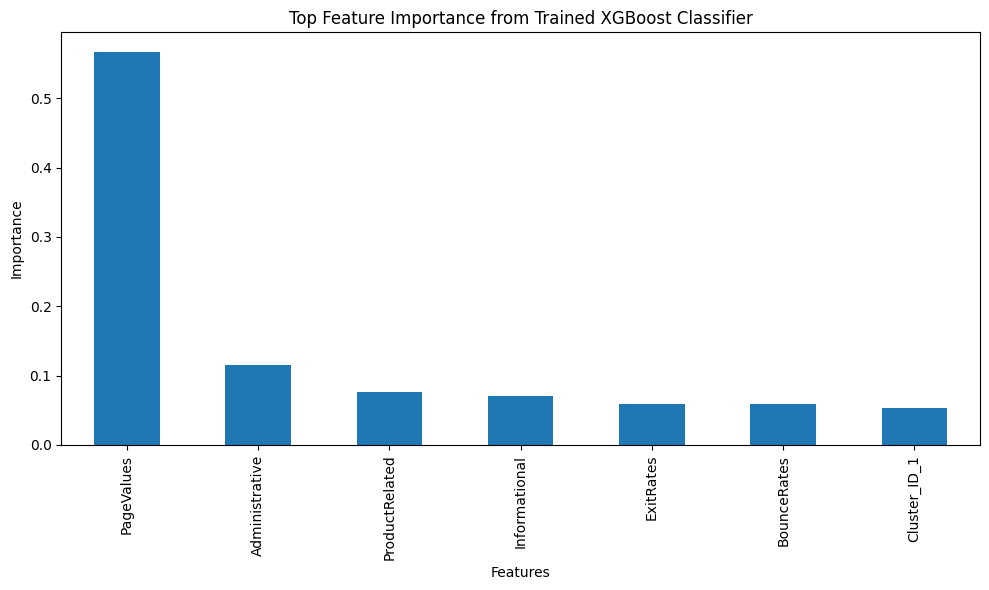

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# Find the XGBoost model within the trained Voting Classifier
xgb_model = None
if hasattr(voting_clf, 'estimators_'):
    for estimator in voting_clf.estimators_:
        if isinstance(estimator, xgb.XGBClassifier):
            xgb_model = estimator
            break

if xgb_model is not None:
    # Get feature importances from the trained XGBoost model
    feature_importances_xgb = xgb_model.feature_importances_

    # Create a pandas Series for easier visualization
    feature_importance_series_xgb = pd.Series(feature_importances_xgb, index=X_processed_df.columns)

    # Sort the features by importance
    sorted_feature_importances_xgb = feature_importance_series_xgb.sort_values(ascending=False)

    # Visualize the top feature importances
    plt.figure(figsize=(10, 6))
    sorted_feature_importances_xgb.head(20).plot(kind='bar')
    plt.title('Top Feature Importance from Trained XGBoost Classifier')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost Classifier not found in the Voting Classifier's estimators (Model might not be fitted yet).")

### Feature Importance from RandomForestClassifier

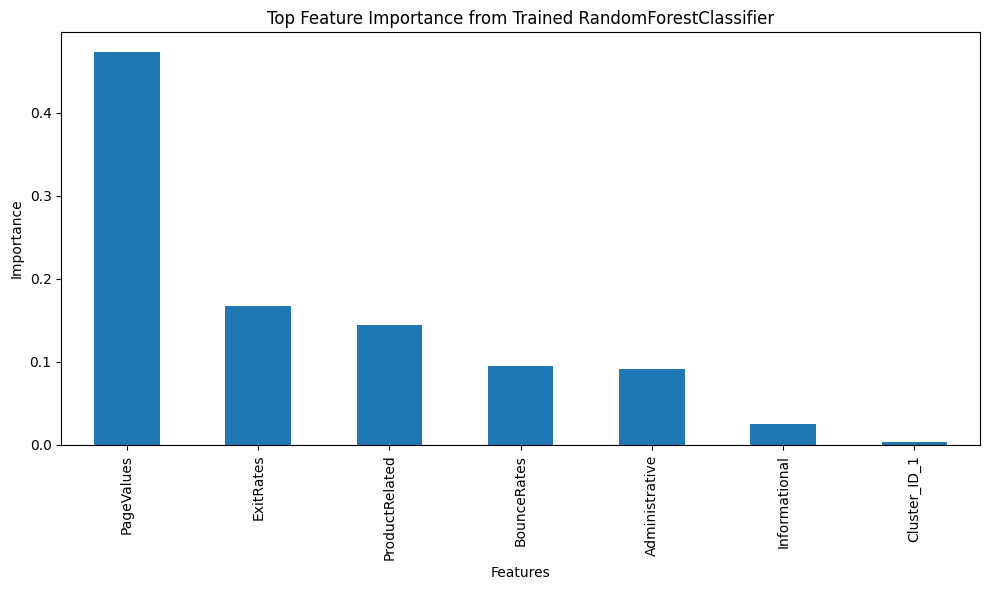

In [126]:
from sklearn.ensemble import RandomForestClassifier

# Get the Random Forest model from the trained Voting Classifier
rf_model = None
if hasattr(voting_clf, 'estimators_'):
    for estimator in voting_clf.estimators_:
        if isinstance(estimator, RandomForestClassifier):
            rf_model = estimator
            break

if rf_model is not None:
    # Get feature importances
    feature_importances = rf_model.feature_importances_
    # Create a pandas Series for easier visualization
    feature_importance_series = pd.Series(feature_importances, index=X_processed_df.columns)
    # Sort the features by importance
    sorted_feature_importances = feature_importance_series.sort_values(ascending=False)
    # Visualize the top 10 feature importances
    plt.figure(figsize=(10, 6))
    sorted_feature_importances.head(20).plot(kind='bar')
    plt.title('Top Feature Importance from Trained RandomForestClassifier')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("RandomForestClassifier not found in the Voting Classifier's estimators.")

**Key Findings from Feature Importance**

*  **PageValues:** This consistently emerged as the most influential feature across all analyses. It indicates the average value for pages a user visited before
completing a transaction. High PageValues strongly correlate with a higher likelihood of purchase, underscoring the importance of user engagement with high-value content.
*  **ExitRates and BounceRates**: These features showed significant negative correlations with purchasing intention. High ExitRates (users leaving from a specific page) and BounceRates (users leaving after viewing only one page) are strong indicators of disengagement and a lower probability of purchase. The models learned to associate these with non-purchasing behavior.
*  **ProductRelated and ProductRelated_Duration**: The number of product-related pages visited and the time spent on them were important, indicating that detailed exploration of products is a strong precursor to purchase.
* **Administrative**: The count of administrative pages visited, while less prominent than PageValues, still contributed to the models' predictive power, suggesting progression through the purchasing funnel.
*  **Cluster_ID_1**: This engineered feature, derived from K-Means clustering, also demonstrated importance, particularly in tree-based models.

## Conclusion


The Voting Classifier model developed in this project is highly effective in predicting online shoppers' purchasing intention, demonstrating robust performance on validation data, especially for the critical 'True' (purchasing) class. Its ability to achieve a high F1 Score, strong Recall, and excellent AUC makes it a valuable tool for e-commerce companies seeking to:

**Target Marketing:** Identify potential purchasers for personalized promotions.

**Optimize User Experience:** Understand behavioral patterns leading to conversion.

**Minimize Lost Sales:** Proactively engage users showing high intent.








